In [2]:
import numpy as np
import cv2 
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from sklearn.cluster import DBSCAN, OPTICS
from scipy.ndimage import sobel
import scipy


plt.rcParams['image.origin'] = 'lower'
plt.rcParams['image.cmap'] = 'gray'
np.set_printoptions(suppress=True)


In [3]:
dir = '/Users/mleclair/phd/code/dunex/data/argus'
file = 'ArgusFF_20211013T170100Z_RectifiedVideo.avi'
os.path.join(dir, file) 

'/Users/mleclair/phd/code/dunex/data/argus/ArgusFF_20211013T170100Z_RectifiedVideo.avi'

In [4]:
cap = cv2.VideoCapture(os.path.join(dir, file))
N = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f'{np.zeros((N, W), dtype=np.uint8).nbytes/1000/1000}mb per timestack')

# NOTE: We're downsampling in along-shore to 10m
skip = 1
timestack = np.zeros((N, H//skip, W))


for i in tqdm(range(N)):
    _, frame = cap.read()
    timestack[i] = frame[::skip, :, 0]

cap.release()
cv2.destroyAllWindows()

1.92mb per timestack


100%|██████████| 3840/3840 [00:06<00:00, 613.55it/s]


In [29]:
timestack = timestack[:300, ...]

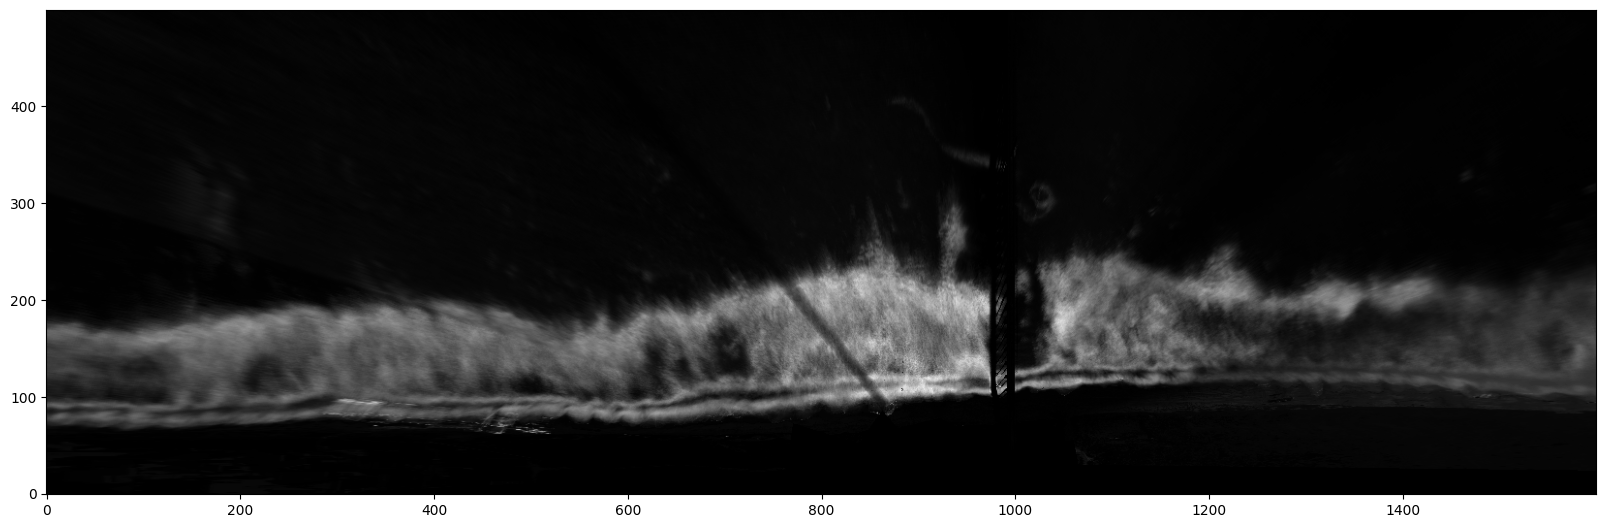

In [33]:
varimage = timestack.var(axis=0)
plt.figure(figsize=(20,20))
plt.imshow(varimage.T)

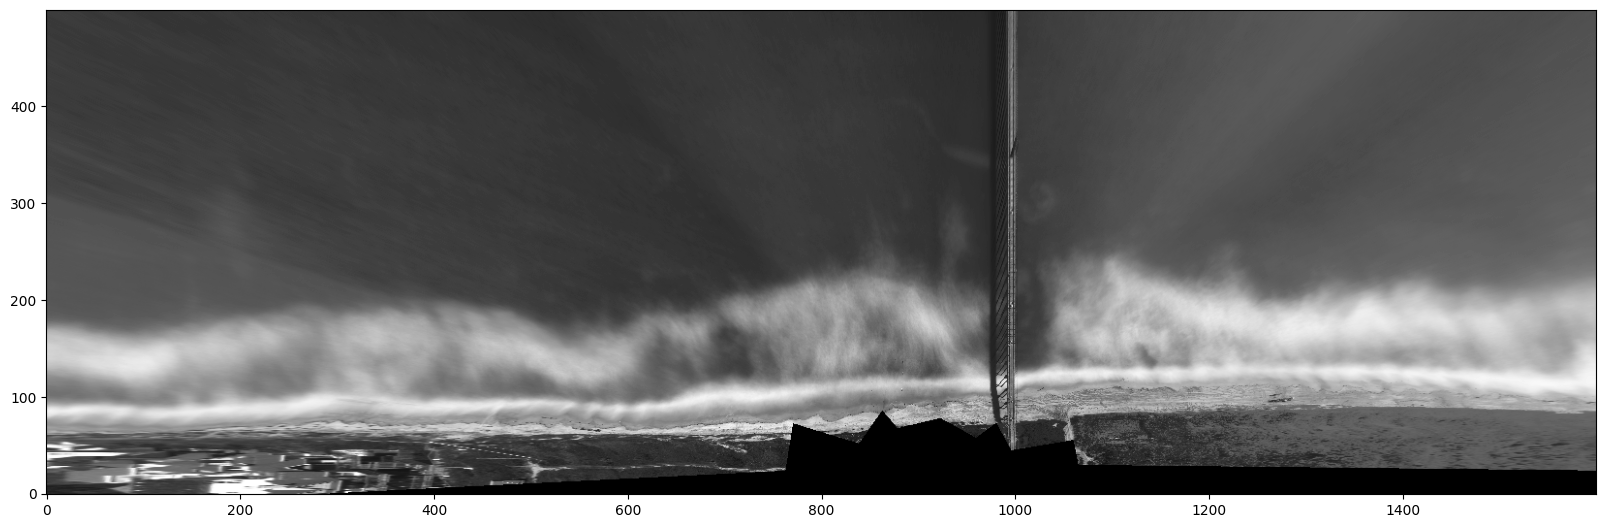

In [34]:
timex = timestack.mean(axis=0)
plt.figure(figsize=(20,20))
plt.imshow(timex.T)